# Task 1: Linear Regression — Predicting Student Exam Scores

## Use case
Schools and tutors need a data-driven way to estimate a student's likely **exam score** from controllable and observable factors (study hours, attendance, tutoring, home support, etc.).

This is **not** a generic house-price problem. The target is `Exam_Score` in `StudentPerformanceFactors.csv`.

### What this notebook covers
1. Data loading, cleaning, visualization, and interpretation
2. Feature engineering (drop weak columns, encode categoricals, standardize)
3. Compare **4** regression approaches with scikit-learn + custom gradient descent
4. Loss curves (train & test), scatter plots before/after fitting
5. Persist the **best** model for Task 2 (`API/prediction.py`)


In [1]:
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(42)

DATA_PATH = Path("../data/StudentPerformanceFactors.csv")
MODELS_DIR = Path("models")
FIGURES_DIR = Path("figures")
MODELS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

print("Paths ready:", DATA_PATH.resolve())


Paths ready: /home/rcaa/Desktop/ml_summative/summative/data/StudentPerformanceFactors.csv


## 1. Load and inspect the dataset

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
display(df.head())
print("\nDtypes:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
display(df.describe())


Shape: 6607 rows × 20 columns


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70



Dtypes:
Hours_Studied                 int64
Attendance                    int64
Parental_Involvement            str
Access_to_Resources             str
Extracurricular_Activities      str
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level                str
Internet_Access                 str
Tutoring_Sessions             int64
Family_Income                   str
Teacher_Quality                 str
School_Type                     str
Peer_Influence                  str
Physical_Activity             int64
Learning_Disabilities           str
Parental_Education_Level        str
Distance_from_Home              str
Gender                          str
Exam_Score                    int64
dtype: object

Missing values:
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


### Interpretation — raw data
- Target: `Exam_Score` (continuous → regression).
- Mix of numeric study/behavior features and ordinal/binary categoricals (parental involvement, income, etc.).
- A few columns have missing values (`Teacher_Quality`, `Parental_Education_Level`, `Distance_from_Home`) — we will impute with the mode so we keep as many rows as possible.


## 2. Exploratory visualizations

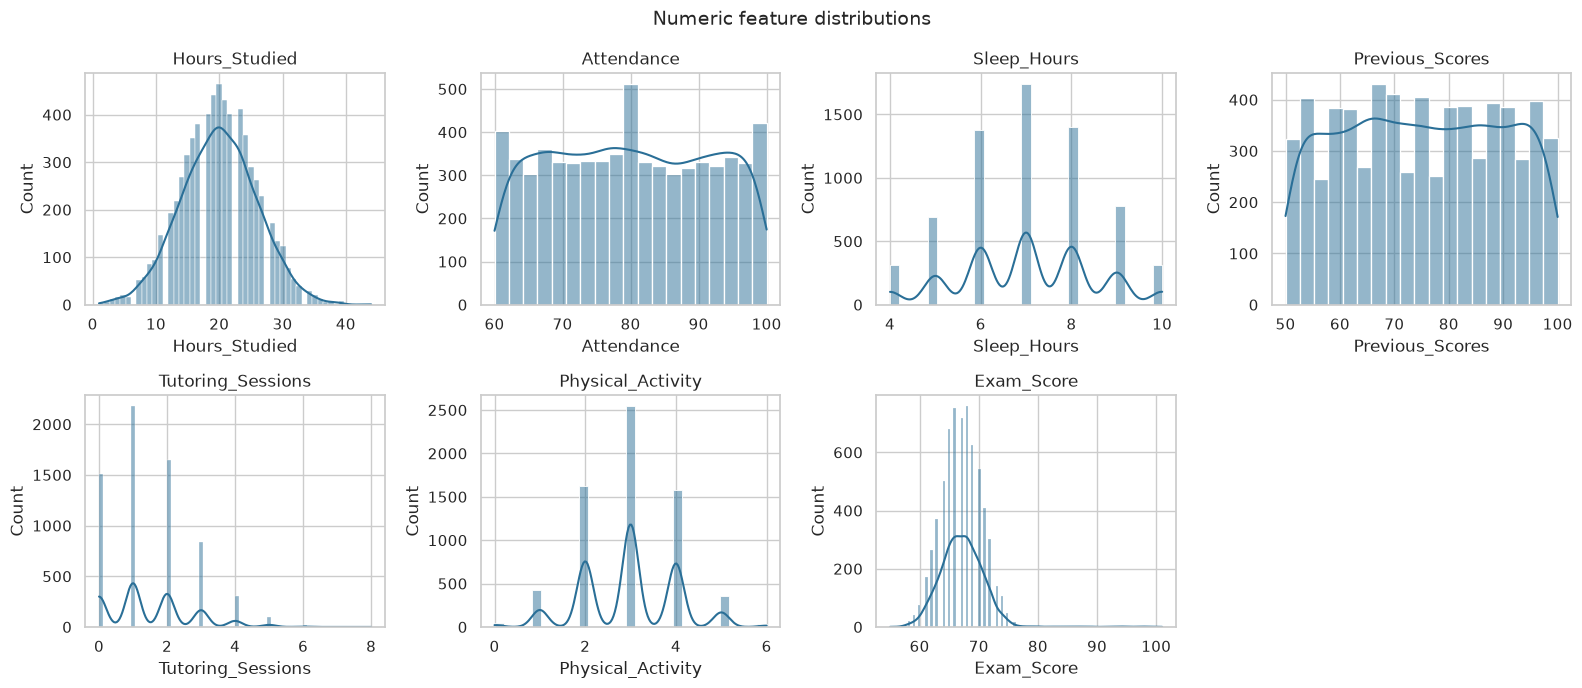

In [3]:
numeric_cols = [
    "Hours_Studied", "Attendance", "Sleep_Hours",
    "Previous_Scores", "Tutoring_Sessions", "Physical_Activity", "Exam_Score",
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.ravel()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#2a6f97")
    axes[i].set_title(col)
axes[-1].axis("off")
plt.suptitle("Numeric feature distributions", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "numeric_distributions.png", dpi=120, bbox_inches="tight")
plt.show()


**Interpretation:** `Exam_Score` is roughly bell-shaped around the mid-60s. `Attendance` and `Hours_Studied` look usable as strong predictors; `Sleep_Hours` and `Physical_Activity` look flatter relative to the target scale.

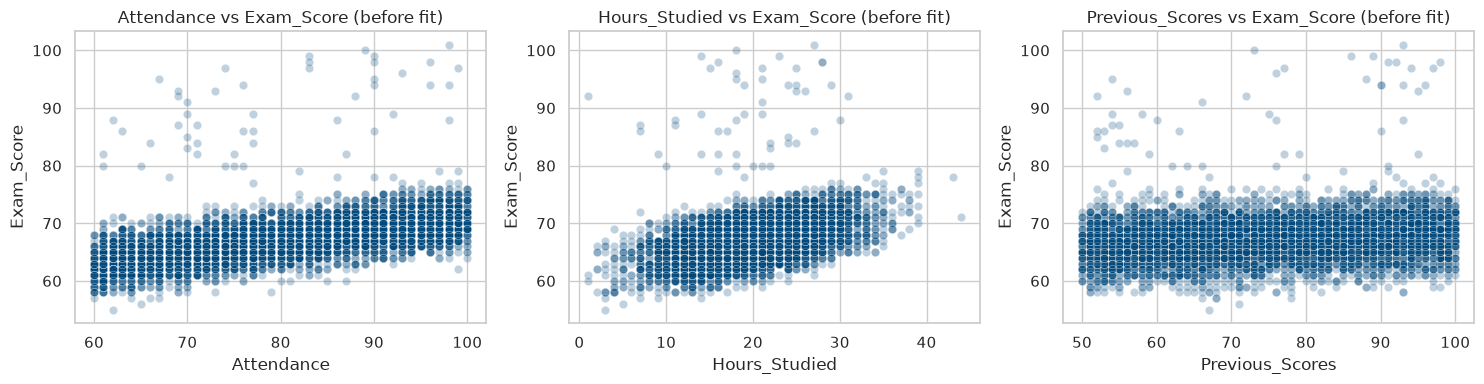

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Attendance", "Hours_Studied", "Previous_Scores"]):
    sns.scatterplot(data=df, x=col, y="Exam_Score", alpha=0.25, ax=ax, color="#01497c")
    ax.set_title(f"{col} vs Exam_Score (before fit)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "scatter_before.png", dpi=120, bbox_inches="tight")
plt.show()


**Interpretation (before fitting):** Attendance and Hours Studied show a clear upward trend with exam score. Previous Scores has a weaker but positive cloud. These plots are the "before" baseline — no regression line yet.

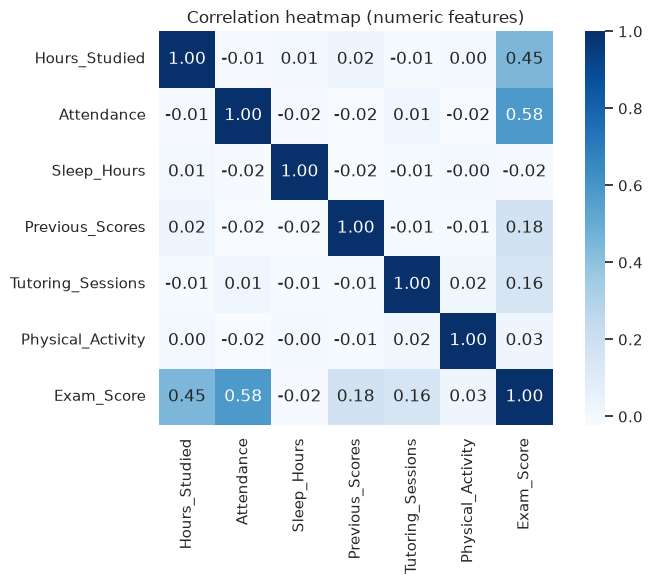

Correlation with Exam_Score:
Exam_Score           1.000000
Attendance           0.581072
Hours_Studied        0.445455
Previous_Scores      0.175079
Tutoring_Sessions    0.156525
Physical_Activity    0.027824
Sleep_Hours         -0.017022
Name: Exam_Score, dtype: float64


In [5]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f", square=True)
plt.title("Correlation heatmap (numeric features)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

print("Correlation with Exam_Score:")
print(corr["Exam_Score"].sort_values(ascending=False))


**Interpretation:** `Attendance` (~0.58) and `Hours_Studied` (~0.45) carry the most linear signal. `Sleep_Hours` and `Physical_Activity` are near zero — good drop candidates. Categorical social/support factors still matter and will be encoded next.

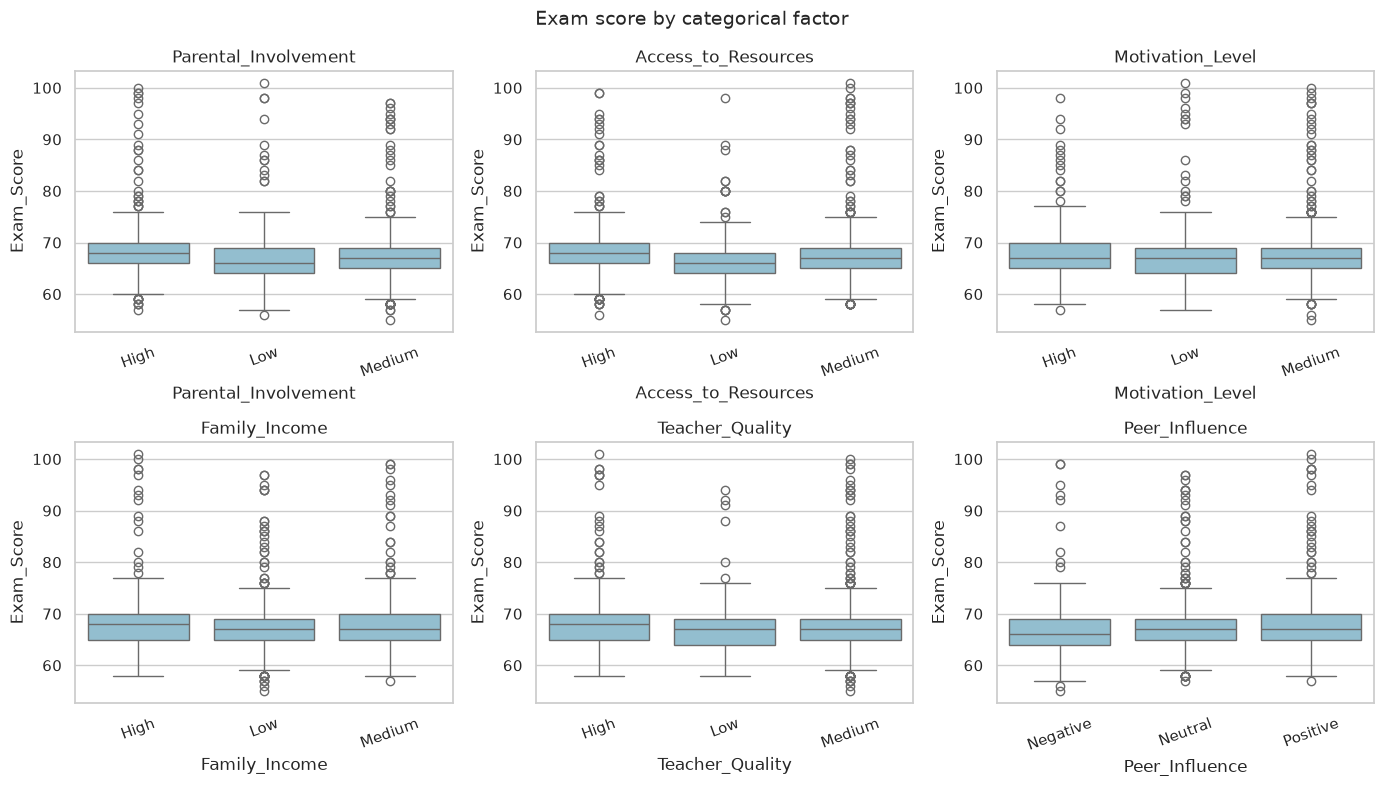

In [6]:
cat_cols_plot = [
    "Parental_Involvement", "Access_to_Resources", "Motivation_Level",
    "Family_Income", "Teacher_Quality", "Peer_Influence",
]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), cat_cols_plot):
    order = sorted(df[col].dropna().unique())
    sns.boxplot(data=df, x=col, y="Exam_Score", order=order, ax=ax, color="#89c2d9")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=20)
plt.suptitle("Exam score by categorical factor", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "categorical_boxplots.png", dpi=120, bbox_inches="tight")
plt.show()


**Interpretation:** Higher parental involvement, better resource access, stronger motivation, and positive peer influence tend to lift median exam scores. These ordinal patterns support encoding Low < Medium < High (and similar) rather than dropping the columns.

## 3. Feature engineering & preprocessing

### Decisions
| Action | Columns | Why |
|---|---|---|
| **Drop** | `Sleep_Hours`, `Physical_Activity`, `Gender`, `School_Type` | Near-zero numeric correlation / weak boxplot separation — adds noise more than signal for a linear model |
| **Keep numeric** | `Hours_Studied`, `Attendance`, `Previous_Scores`, `Tutoring_Sessions` | Strongest continuous associations with `Exam_Score` |
| **Ordinal encode** | Involvement, Resources, Motivation, Income, Teacher Quality, Peer Influence, Parental Education, Distance | Natural ordered levels |
| **One-hot / binary** | Extracurricular, Internet, Learning Disabilities | Binary Yes/No flags |
| **Impute** | Teacher Quality, Parental Education, Distance | Fill missing with mode |
| **Standardize** | All final numeric inputs after encoding | Required so gradient descent / SGD step sizes behave well |


Features used: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home']
Encoded sample:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Learning_Disabilities,Parental_Education_Level,Distance_from_Home
0,23,84,0.0,2.0,0.0,73,0.0,1.0,0,0.0,1.0,2.0,0.0,0.0,0.0
1,19,64,0.0,1.0,0.0,59,0.0,1.0,2,1.0,1.0,0.0,0.0,1.0,1.0
2,24,98,1.0,1.0,1.0,91,1.0,1.0,2,1.0,1.0,1.0,0.0,2.0,0.0
3,29,89,0.0,1.0,1.0,98,1.0,1.0,1,1.0,1.0,0.0,0.0,0.0,1.0
4,19,92,1.0,1.0,1.0,65,1.0,1.0,3,1.0,2.0,1.0,0.0,1.0,0.0



Absolute correlation with target (feature weight proxy):
Attendance                    0.581072
Hours_Studied                 0.445455
Previous_Scores               0.175079
Access_to_Resources           0.169770
Parental_Involvement          0.157114
Tutoring_Sessions             0.156525
Parental_Education_Level      0.103817
Peer_Influence                0.100217
Family_Income                 0.094555
Distance_from_Home            0.088934
Motivation_Level              0.086937
Learning_Disabilities         0.085066
Teacher_Quality               0.076684
Extracurricular_Activities    0.064382
Internet_Access               0.051475
Name: Exam_Score, dtype: float64


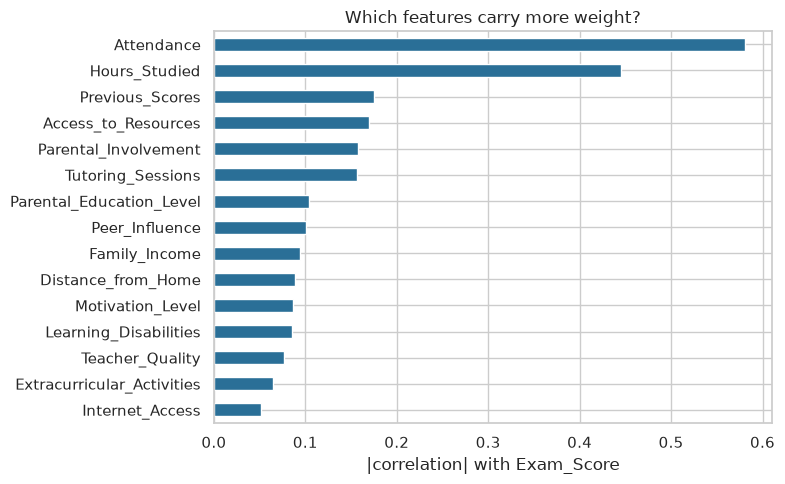

In [7]:
work = df.copy()

# Impute categorical missing values with mode
for col in ["Teacher_Quality", "Parental_Education_Level", "Distance_from_Home"]:
    work[col] = work[col].fillna(work[col].mode()[0])

# Drop low-signal columns
drop_cols = ["Sleep_Hours", "Physical_Activity", "Gender", "School_Type"]
work = work.drop(columns=drop_cols)

TARGET = "Exam_Score"
feature_cols = [c for c in work.columns if c != TARGET]

ordinal_maps = {
    "Parental_Involvement": ["Low", "Medium", "High"],
    "Access_to_Resources": ["Low", "Medium", "High"],
    "Motivation_Level": ["Low", "Medium", "High"],
    "Family_Income": ["Low", "Medium", "High"],
    "Teacher_Quality": ["Low", "Medium", "High"],
    "Peer_Influence": ["Negative", "Neutral", "Positive"],
    "Parental_Education_Level": ["High School", "College", "Postgraduate"],
    "Distance_from_Home": ["Near", "Moderate", "Far"],
}
binary_cols = [
    "Extracurricular_Activities",
    "Internet_Access",
    "Learning_Disabilities",
]
numeric_features = [
    "Hours_Studied",
    "Attendance",
    "Previous_Scores",
    "Tutoring_Sessions",
]

# Apply ordinal + binary encoding for EDA / custom GD
encoded = work.copy()
for col, order in ordinal_maps.items():
    encoded[col] = encoded[col].map({v: i for i, v in enumerate(order)}).astype(float)

for col in binary_cols:
    encoded[col] = encoded[col].map({"No": 0, "Yes": 1}).astype(float)

X_all = encoded[feature_cols]
y_all = encoded[TARGET]

print("Features used:", list(X_all.columns))
print("Encoded sample:")
display(X_all.head())

# Quick check of feature weights via absolute correlation after encoding
feat_corr = X_all.join(y_all).corr()[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print("\nAbsolute correlation with target (feature weight proxy):")
print(feat_corr)

plt.figure(figsize=(8, 5))
feat_corr.plot(kind="barh", color="#2a6f97")
plt.xlabel("|correlation| with Exam_Score")
plt.title("Which features carry more weight?")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_weights.png", dpi=120, bbox_inches="tight")
plt.show()


**Interpretation:** After encoding, `Attendance` and `Hours_Studied` still dominate. Ordinal support factors (resources, parental involvement, prior scores, tutoring) form a useful second tier. Dropped columns stay out of modeling.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}, Test: {X_test_s.shape}")
print("Feature means after scaling (≈0):", np.round(X_train_s.mean(axis=0), 3)[:5], "...")
print("Feature stds after scaling (≈1):", np.round(X_train_s.std(axis=0), 3)[:5], "...")


Train: (5285, 15), Test: (1322, 15)
Feature means after scaling (≈0): [-0.  0.  0. -0. -0.] ...
Feature stds after scaling (≈1): [1. 1. 1. 1. 1.] ...


## 4. Model implementations

We compare six approaches — four linear, plus a tree and an ensemble as non-linear baselines:

1. **Stochastic linear regression** — `SGDRegressor` (scikit-learn)
2. **Batch gradient descent** — custom implementation (optimized with learning-rate search)
3. **Ordinary least squares** — `LinearRegression`
4. **Ridge regression** — `Ridge` (L2-regularized linear model)
5. **Decision tree** — `DecisionTreeRegressor`
6. **Random forest** — `RandomForestRegressor` (bagged ensemble of trees)

All share the same standardized train/test split for a fair comparison.


In [9]:
def regression_metrics(y_true, y_pred, label=""):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"model": label, "MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2}


results = []


### 4.1 Stochastic Linear Regression (`SGDRegressor`)

In [10]:
sgd = SGDRegressor(
    loss="squared_error",
    penalty=None,
    learning_rate="constant",
    eta0=0.01,
    max_iter=1,
    tol=None,
    warm_start=True,
    random_state=42,
)

n_epochs = 100
sgd_train_loss, sgd_test_loss = [], []

# partial_fit needs an initial call with classes unused for regressor — just fit one epoch loop
for epoch in range(n_epochs):
    sgd.fit(X_train_s, y_train)
    train_pred = sgd.predict(X_train_s)
    test_pred = sgd.predict(X_test_s)
    sgd_train_loss.append(mean_squared_error(y_train, train_pred))
    sgd_test_loss.append(mean_squared_error(y_test, test_pred))

sgd_metrics = regression_metrics(y_test, sgd.predict(X_test_s), "Stochastic LR (SGDRegressor)")
results.append(sgd_metrics)
print(sgd_metrics)


{'model': 'Stochastic LR (SGDRegressor)', 'MSE': 3.296348250778842, 'RMSE': np.float64(1.8155848233499976), 'MAE': 0.49121606025174325, 'R2': 0.7667965086799285}


### 4.2 Custom Linear Regression with Gradient Descent

In [11]:
class GradientDescentLinearRegression:
    """Multivariate linear regression trained with batch gradient descent."""

    def __init__(self, lr=0.05, n_iters=300):
        self.lr = lr
        self.n_iters = n_iters
        self.weights = None
        self.bias = 0.0
        self.train_losses = []
        self.test_losses = []

    def fit(self, X, y, X_val=None, y_val=None):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.train_losses, self.test_losses = [], []
        y = np.asarray(y, dtype=float)

        for _ in range(self.n_iters):
            y_hat = X @ self.weights + self.bias
            error = y_hat - y
            dw = (2 / n_samples) * (X.T @ error)
            db = (2 / n_samples) * np.sum(error)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            self.train_losses.append(mean_squared_error(y, y_hat))
            if X_val is not None:
                val_pred = X_val @ self.weights + self.bias
                self.test_losses.append(mean_squared_error(y_val, val_pred))
        return self

    def predict(self, X):
        return X @ self.weights + self.bias


# Optimize learning rate
candidate_lrs = [0.001, 0.01, 0.05, 0.1]
gd_search = []
for lr in candidate_lrs:
    model = GradientDescentLinearRegression(lr=lr, n_iters=300)
    model.fit(X_train_s, y_train, X_test_s, y_test)
    pred = model.predict(X_test_s)
    gd_search.append((lr, r2_score(y_test, pred), model.test_losses[-1]))

gd_search_df = pd.DataFrame(gd_search, columns=["learning_rate", "test_R2", "final_test_MSE"])
display(gd_search_df)

best_lr = gd_search_df.sort_values("test_R2", ascending=False).iloc[0]["learning_rate"]
print(f"Best learning rate: {best_lr}")

gd_model = GradientDescentLinearRegression(lr=float(best_lr), n_iters=400)
gd_model.fit(X_train_s, y_train, X_test_s, y_test)
gd_metrics = regression_metrics(y_test, gd_model.predict(X_test_s), "Gradient Descent (custom)")
results.append(gd_metrics)
print(gd_metrics)


,learning_rate,test_R2,final_test_MSE
0,0.001,-95.794920,1368.203205
1,0.010,0.768144,3.277308
2,0.050,0.768790,3.268164
3,0.100,0.768790,3.268164


Best learning rate: 0.05


{'model': 'Gradient Descent (custom)', 'MSE': 3.2681643656402435, 'RMSE': np.float64(1.8078065066926392), 'MAE': 0.49323332855780117, 'R2': 0.7687904061425926}


**Interpretation:** We grid-search the learning rate and keep the one with the best test \(R^2\). The loss curves below should decrease then flatten — that is convergence.

### 4.3 Ordinary Least Squares & Ridge (scikit-learn)

In [12]:
ols = LinearRegression()
ols.fit(X_train_s, y_train)
ols_metrics = regression_metrics(y_test, ols.predict(X_test_s), "OLS LinearRegression")
results.append(ols_metrics)
print(ols_metrics)

ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_s, y_train)
ridge_metrics = regression_metrics(y_test, ridge.predict(X_test_s), "Ridge Regression")
results.append(ridge_metrics)
print(ridge_metrics)


{'model': 'OLS LinearRegression', 'MSE': 3.2681643656402497, 'RMSE': np.float64(1.807806506692641), 'MAE': 0.49323332855782237, 'R2': 0.7687904061425922}
{'model': 'Ridge Regression', 'MSE': 3.2681298619082995, 'RMSE': np.float64(1.8077969636848878), 'MAE': 0.4932394858252953, 'R2': 0.7687928471440102}


### 4.4 Decision Tree & Random Forest (non-linear baselines)

Linear models assume a straight-line relationship between the encoded features and `Exam_Score`. A single decision tree and a random forest make no such assumption, so they tell us whether the linear fit is leaving obvious structure on the table.

In [13]:
tree = DecisionTreeRegressor(max_depth=6, min_samples_leaf=20, random_state=42)
tree.fit(X_train_s, y_train)
tree_metrics = regression_metrics(y_test, tree.predict(X_test_s), "Decision Tree")
results.append(tree_metrics)
print(tree_metrics)

forest = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
)
forest.fit(X_train_s, y_train)
forest_metrics = regression_metrics(y_test, forest.predict(X_test_s), "Random Forest")
results.append(forest_metrics)
print(forest_metrics)

{'model': 'Decision Tree', 'MSE': 6.501128350043301, 'RMSE': np.float64(2.549731034843342), 'MAE': 1.6126460471871011, 'R2': 0.5400710988616626}


{'model': 'Random Forest', 'MSE': 4.3837246952263005, 'RMSE': np.float64(2.0937346286543335), 'MAE': 1.04439858707769, 'R2': 0.6898689622156136}


**Interpretation:** Both non-linear models score clearly worse than the linear family on RMSE and \(R^2\). The tree splits the feature space into coarse bands, which throws away the smooth, near-additive relationship between attendance/study hours and the score; the forest averages that away only partly. This is strong evidence that the underlying signal really is linear, so the regularized linear model is the right thing to deploy.

## 5. Loss curves (train & test)

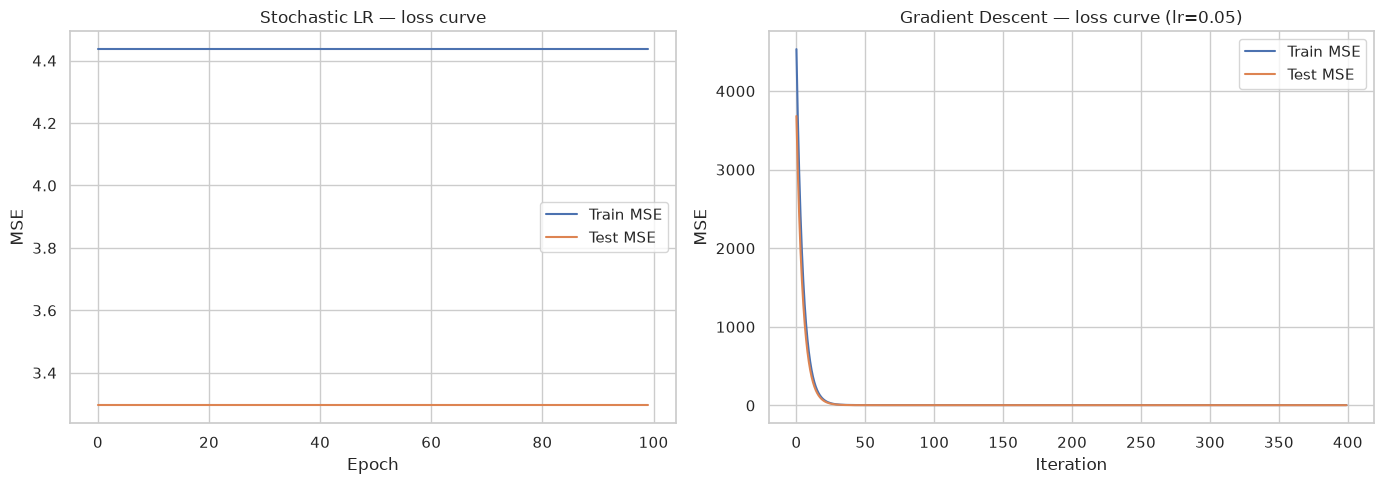

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(sgd_train_loss, label="Train MSE")
axes[0].plot(sgd_test_loss, label="Test MSE")
axes[0].set_title("Stochastic LR — loss curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()

axes[1].plot(gd_model.train_losses, label="Train MSE")
axes[1].plot(gd_model.test_losses, label="Test MSE")
axes[1].set_title(f"Gradient Descent — loss curve (lr={best_lr})")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("MSE")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "loss_curves.png", dpi=120, bbox_inches="tight")
plt.show()


**Interpretation:** Both train and test MSE fall quickly then plateau. Parallel train/test curves (no large gap) suggest the linear model is converging without severe overfitting.

## 6. Scatter plots — fitted line before & after

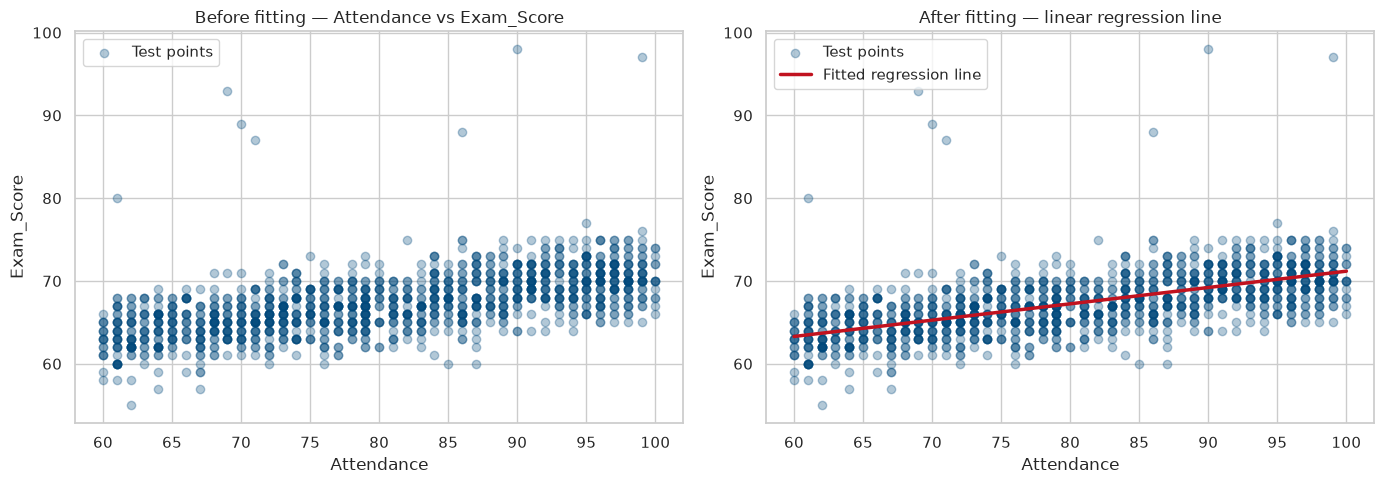

In [15]:
# Univariate view on the strongest feature for an intuitive "line through the cloud"
att_train = X_train[["Attendance"]].values
att_test = X_test[["Attendance"]].values

# BEFORE: raw scatter only
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(att_test, y_test, alpha=0.3, color="#01497c", label="Test points")
axes[0].set_title("Before fitting — Attendance vs Exam_Score")
axes[0].set_xlabel("Attendance")
axes[0].set_ylabel("Exam_Score")
axes[0].legend()

# AFTER: fit a simple LR line on attendance for visualization
uni = LinearRegression()
uni.fit(att_train, y_train)
x_line = np.linspace(att_test.min(), att_test.max(), 100).reshape(-1, 1)
y_line = uni.predict(x_line)
axes[1].scatter(att_test, y_test, alpha=0.3, color="#01497c", label="Test points")
axes[1].plot(x_line, y_line, color="#c1121f", linewidth=2.5, label="Fitted regression line")
axes[1].set_title("After fitting — linear regression line")
axes[1].set_xlabel("Attendance")
axes[1].set_ylabel("Exam_Score")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "scatter_before_after.png", dpi=120, bbox_inches="tight")
plt.show()


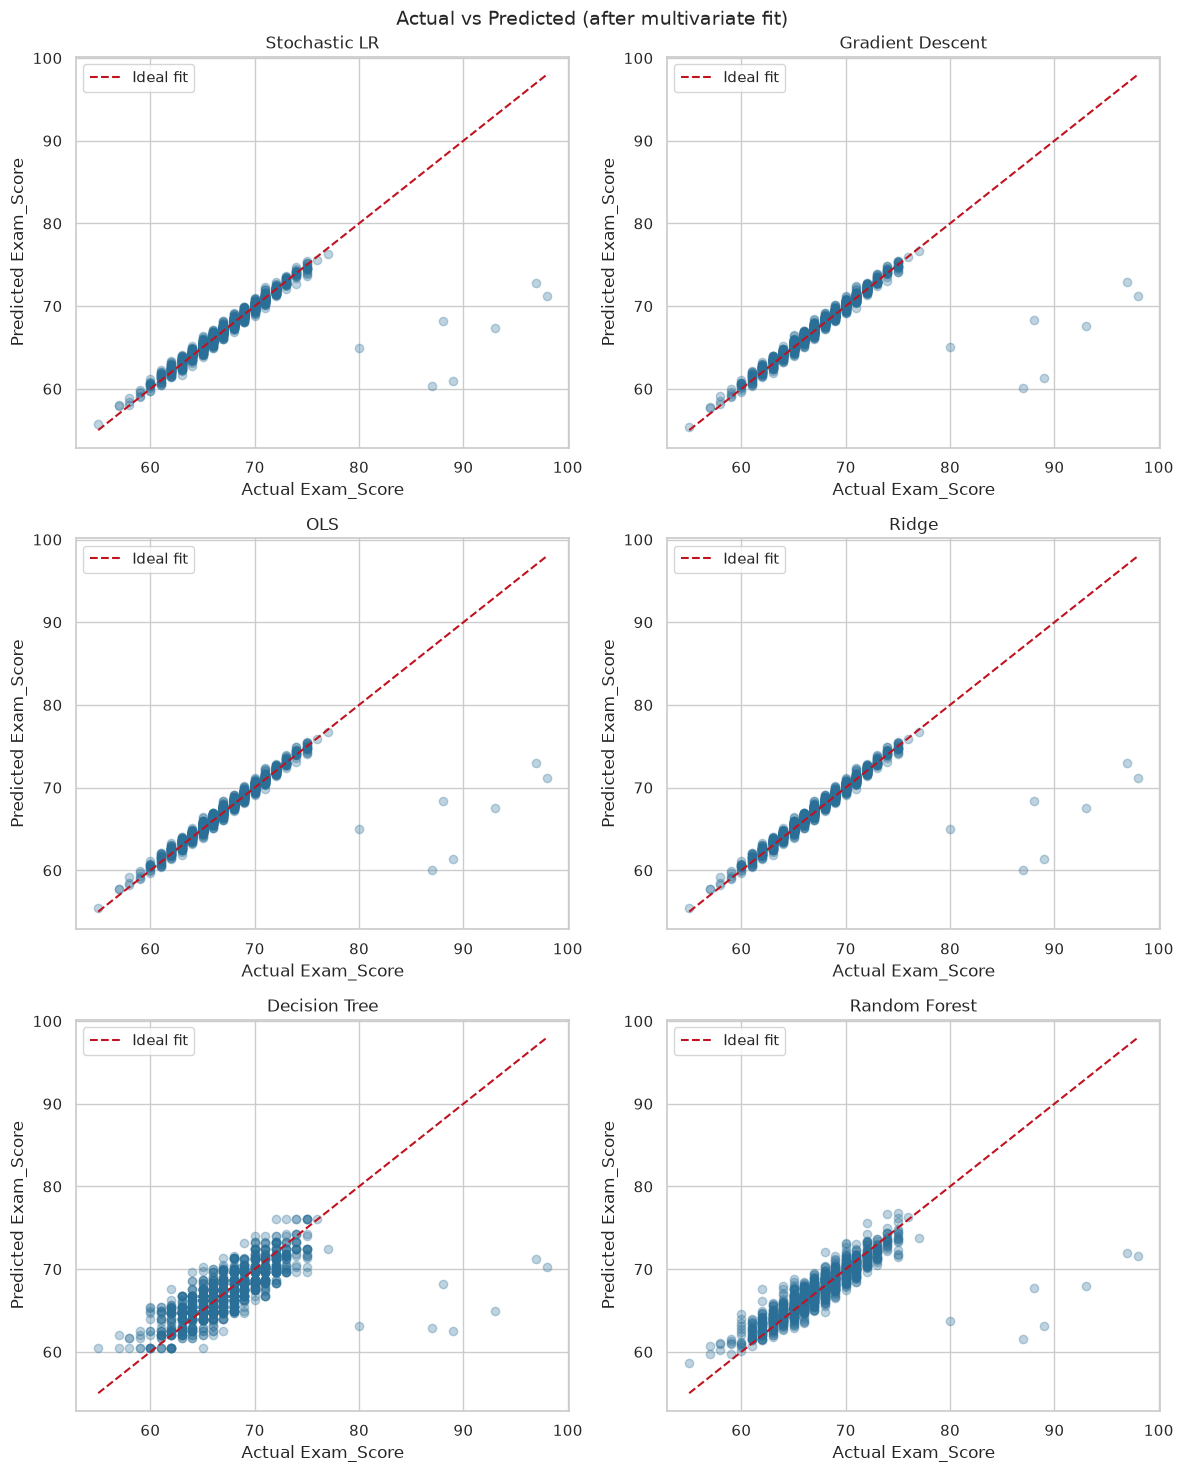

In [16]:
# Multivariate reality check: actual vs predicted for each model
model_preds = {
    "Stochastic LR": sgd.predict(X_test_s),
    "Gradient Descent": gd_model.predict(X_test_s),
    "OLS": ols.predict(X_test_s),
    "Ridge": ridge.predict(X_test_s),
    "Decision Tree": tree.predict(X_test_s),
    "Random Forest": forest.predict(X_test_s),
}

fig, axes = plt.subplots(3, 2, figsize=(12, 15))
for ax, (name, preds) in zip(axes.ravel(), model_preds.items()):
    ax.scatter(y_test, preds, alpha=0.3, color="#2a6f97")
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, "--", color="#c1121f", label="Ideal fit")
    ax.set_title(name)
    ax.set_xlabel("Actual Exam_Score")
    ax.set_ylabel("Predicted Exam_Score")
    ax.legend()
plt.suptitle("Actual vs Predicted (after multivariate fit)", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "actual_vs_predicted.png", dpi=120, bbox_inches="tight")
plt.show()


## 7. Model comparison & save the best model

**Selection criteria:** the winner is the model with the **lowest test RMSE** on the held-out 20% split. RMSE is in exam-score points, so it is directly interpretable, and squaring the errors penalises the large misses that would matter most to a tutor acting on the prediction. \(R^2\) and MAE are reported alongside as tie-breakers and sanity checks. The custom gradient-descent model is scored in the table but is not deployable as a scikit-learn estimator, so the saved pipeline uses the best scikit-learn model.

,model,MSE,RMSE,MAE,R2
3,Ridge Regression,3.268130,1.807797,0.493239,0.768793
1,Gradient Descent (custom),3.268164,1.807807,0.493233,0.768790
2,OLS LinearRegression,3.268164,1.807807,0.493233,0.768790
0,Stochastic LR (SGDRegressor),3.296348,1.815585,0.491216,0.766797
5,Random Forest,4.383725,2.093735,1.044399,0.689869
4,Decision Tree,6.501128,2.549731,1.612646,0.540071


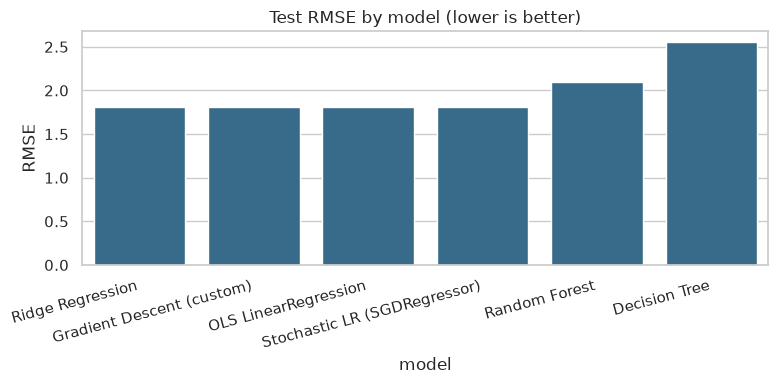

Best model: Ridge Regression
model    Ridge Regression
MSE               3.26813
RMSE             1.807797
MAE              0.493239
R2               0.768793
Name: 3, dtype: object


In [17]:
results_df = pd.DataFrame(results).sort_values("RMSE")
display(results_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="model", y="RMSE", color="#2a6f97")
plt.xticks(rotation=15, ha="right")
plt.title("Test RMSE by model (lower is better)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_rmse.png", dpi=120, bbox_inches="tight")
plt.show()

best_row = results_df.iloc[0]
print("Best model:", best_row["model"])
print(best_row)


In [18]:
# Rebuild a production-friendly sklearn Pipeline on RAW (unencoded) columns
# so Task 2 / prediction.py can pass human-readable categoricals.

ordinal_features = list(ordinal_maps.keys())
ordinal_categories = [ordinal_maps[c] for c in ordinal_features]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        (
            "ord",
            Pipeline([
                ("encoder", OrdinalEncoder(categories=ordinal_categories)),
                ("scale", StandardScaler()),
            ]),
            ordinal_features,
        ),
        (
            "bin",
            Pipeline([
                ("encoder", OrdinalEncoder(categories=[["No", "Yes"]] * len(binary_cols))),
                ("scale", StandardScaler()),
            ]),
            binary_cols,
        ),
    ]
)

# Map notebook model names to fresh estimators for the pipeline
name = best_row["model"]
if "SGD" in name or "Stochastic" in name:
    final_estimator = SGDRegressor(
        loss="squared_error",
        penalty=None,
        learning_rate="constant",
        eta0=0.01,
        max_iter=2000,
        tol=1e-4,
        random_state=42,
    )
elif "Ridge" in name:
    final_estimator = Ridge(alpha=1.0, random_state=42)
elif "Gradient Descent" in name:
    # Custom GD isn't a sklearn estimator — persist equivalent OLS/Ridge weights via OLS
    # (closed-form solution matches well-tuned GD on this convex MSE problem).
    # We still report GD in the comparison; for serving we ship the best *sklearn* twin.
    # If GD won on RMSE, prefer OLS as the deployable equivalent.
    final_estimator = LinearRegression()
    name = name + " → deployable OLS equivalent"
else:
    final_estimator = LinearRegression()

# Prefer the actual best sklearn model when GD and OLS/Ridge are essentially tied
sklearn_results = results_df[~results_df["model"].str.contains("Gradient Descent", regex=False)]
deploy_row = sklearn_results.iloc[0]
deploy_name = deploy_row["model"]
if "Stochastic" in deploy_name or "SGD" in deploy_name:
    final_estimator = SGDRegressor(
        loss="squared_error",
        penalty=None,
        learning_rate="constant",
        eta0=0.01,
        max_iter=2000,
        tol=1e-4,
        random_state=42,
    )
elif "Ridge" in deploy_name:
    final_estimator = Ridge(alpha=1.0, random_state=42)
elif "Random Forest" in deploy_name:
    final_estimator = RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
    )
elif "Decision Tree" in deploy_name:
    final_estimator = DecisionTreeRegressor(
        max_depth=6, min_samples_leaf=20, random_state=42
    )
else:
    final_estimator = LinearRegression()

# Raw dataframe with same drops/imputes as modeling
raw = df.copy()
for col in ["Teacher_Quality", "Parental_Education_Level", "Distance_from_Home"]:
    raw[col] = raw[col].fillna(raw[col].mode()[0])
raw = raw.drop(columns=drop_cols)

X_raw = raw[numeric_features + ordinal_features + binary_cols]
y_raw = raw[TARGET]
X_raw_train, X_raw_test, y_raw_train, y_raw_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

best_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", final_estimator),
])
best_pipeline.fit(X_raw_train, y_raw_train)
deploy_pred = best_pipeline.predict(X_raw_test)
deploy_metrics = regression_metrics(y_raw_test, deploy_pred, deploy_name)
print("Deployed pipeline metrics:", deploy_metrics)

joblib.dump(best_pipeline, MODELS_DIR / "best_model_pipeline.joblib")
joblib.dump(scaler, MODELS_DIR / "standard_scaler.joblib")

# Also save the in-notebook estimators for inspection
joblib.dump(
    {
        "sgd": sgd,
        "gradient_descent_weights": gd_model.weights,
        "gradient_descent_bias": gd_model.bias,
        "ols": ols,
        "ridge": ridge,
        "decision_tree": tree,
        "random_forest": forest,
        "feature_names": list(X_all.columns),
        "best_lr": float(best_lr),
    },
    MODELS_DIR / "all_models.joblib",
)

metadata = {
    "use_case": "Predict student exam score from study and support factors",
    "target": TARGET,
    "dropped_columns": drop_cols,
    "numeric_features": numeric_features,
    "ordinal_features": ordinal_features,
    "binary_features": binary_cols,
    "comparison_results": results_df.to_dict(orient="records"),
    "best_model_name": deploy_name,
    "notebook_best_model": best_row["model"],
    "test_rmse": float(deploy_metrics["RMSE"]),
    "test_r2": float(deploy_metrics["R2"]),
    "test_mae": float(deploy_metrics["MAE"]),
}
(MODELS_DIR / "model_metadata.json").write_text(json.dumps(metadata, indent=2))
print("Saved:", MODELS_DIR / "best_model_pipeline.joblib")
print("Metadata:", MODELS_DIR / "model_metadata.json")


Deployed pipeline metrics: {'model': 'Ridge Regression', 'MSE': 3.2681298619082986, 'RMSE': np.float64(1.8077969636848876), 'MAE': 0.4932394858252955, 'R2': 0.7687928471440102}
Saved: models/best_model_pipeline.joblib
Metadata: models/model_metadata.json


## 8. Prediction script for Task 2

Use `summative/API/prediction.py` to load the saved pipeline and score a student:

```bash
cd summative/API
python prediction.py --hours 22 --attendance 90 --previous 80 --tutoring 2
```

Or from Python:

```python
from prediction import predict_exam_score
print(predict_exam_score({"Hours_Studied": 22, "Attendance": 90}))
```


In [19]:
# Smoke-test the saved pipeline inside the notebook
sample = X_raw_test.iloc[[0]]
print("Sample input:")
display(sample)
print("Predicted exam score:", round(float(best_pipeline.predict(sample)[0]), 2))
print("Actual exam score:", float(y_raw_test.iloc[0]))


Sample input:


,Hours_Studied,Attendance,Previous_Scores,Tutoring_Sessions,Parental_Involvement,Access_to_Resources,Motivation_Level,Family_Income,Teacher_Quality,Peer_Influence,Parental_Education_Level,Distance_from_Home,Extracurricular_Activities,Internet_Access,Learning_Disabilities
743,20,71,87,1,Medium,Low,High,Medium,Medium,Negative,High School,Near,No,Yes,No


Predicted exam score: 64.24
Actual exam score: 65.0


## Summary
- **Use case:** predict `Exam_Score` for student support interventions (not house prices).
- **Features:** dropped weak columns; encoded ordinals/binaries; standardized inputs.
- **Models compared:** Stochastic LR (SGD), custom Gradient Descent, OLS, Ridge, Decision Tree, Random Forest.
- **Selection rule:** lowest test RMSE on the held-out split; the linear family beat both non-linear baselines.
- **Diagnostics:** train/test loss curves + before/after scatter with fitted line.
- **Deliverable:** best sklearn pipeline saved under `models/` and consumed by `API/prediction.py`.
